In [ ]:
!pip install transformers torch scikit-learn pandas -q

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import torch

In [ ]:
# Load Data
BASE_PATH = "/content/drive/My Drive/LUT-Fake News Detection/"

train_df = pd.read_csv(BASE_PATH + "train.csv")
val_df   = pd.read_csv(BASE_PATH + "validate.csv")
test_df  = pd.read_csv(BASE_PATH + "test.csv")

print(f"Train    : {len(train_df):>10,} rows")
print(f"Validate : {len(val_df):>10,} rows")
print(f"Test     : {len(test_df):>10,} rows")
print(f"\nColumns  : {train_df.columns.tolist()}")
print(f"\nSample row:\n{train_df.iloc[0]}")

KeyboardInterrupt: 

In [ ]:
#Label mapping & subsample

LABEL_MAP = {
    'reliable'  : 1,
    'fake'      : 0,
    'unreliable': 0,
    'conspiracy': 0,
    'rumor'     : 0,
    'junksci'   : 0,
    'clickbait' : 0,
    'hate'      : 0,
    'satire'    : 0,
    'political' : None,
    'bias'      : None,
    'unknown'   : None,
}

def apply_labels(df, name):
    df = df.copy()
    df['label'] = df['type'].map(LABEL_MAP)
    before = len(df)
    df = df.dropna(subset=['label'])
    df['label'] = df['label'].astype(int)
    after = len(df)
    print(f"[{name}] Dropped {before - after:,} rows | Remaining: {after:,}")
    print(f"  Reliable (1): {(df['label']==1).sum():,} | Fake (0): {(df['label']==0).sum():,}")
    return df

train_df = apply_labels(train_df, "train")
val_df   = apply_labels(val_df,   "validate")
test_df  = apply_labels(test_df,  "test")

[train] Dropped 1,294,376 rows | Remaining: 2,155,342
  Reliable (1): 891,202 | Fake (0): 1,264,140
[validate] Dropped 161,798 rows | Remaining: 269,417
  Reliable (1): 111,400 | Fake (0): 158,017
[test] Dropped 161,797 rows | Remaining: 269,418
  Reliable (1): 111,401 | Fake (0): 158,017


# Stratified Subsample

DistilBERT is too slow to train on 2.7M rows with free Colab. We take a stratified 7% sample - same fake/reliable ratio preserved. This is scientifically valid and matches Part 2's guidance on not needing to use the full corpus.

In [ ]:
from sklearn.model_selection import train_test_split

SAMPLE_FRAC = 0.07
RANDOM_SEED = 42

def stratified_sample(df, frac, name):
    # We just do a stratified split and keep the smaller portion
    _, sampled = train_test_split(
        df,
        test_size=frac,
        random_state=RANDOM_SEED,
        stratify=df['label']   # preserves fake/reliable ratio
    )
    sampled = sampled.reset_index(drop=True)
    print(f"[{name}] {len(df):,} → {len(sampled):,} rows (frac={frac})")
    print(f"  Reliable (1): {(sampled['label']==1).sum():,} | Fake (0): {(sampled['label']==0).sum():,}")
    return sampled

train_sample = stratified_sample(train_df, SAMPLE_FRAC, "train")

print(f"\nFinal sizes:")
print(f"  Train (sampled) : {len(train_sample):,}")
print(f"  Validate (full) : {len(val_df):,}")
print(f"  Test (full)     : {len(test_df):,}")

[train] 2,155,342 → 150,874 rows (frac=0.07)
  Reliable (1): 62,384 | Fake (0): 88,490

Final sizes:
  Train (sampled) : 150,874
  Validate (full) : 269,417
  Test (full)     : 269,418


## Confirm GPU

In [ ]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device : {device}")

if device.type == "cuda":
    print(f"GPU name     : {torch.cuda.get_device_name(0)}")
    print(f"Memory       : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("No GPU found. Please check Runtime & change runtime type!")

Using device : cuda
GPU name     : Tesla T4
Memory       : 15.6 GB


## Load Tokenizer & Build PyTorch Dataset

In [ ]:
from transformers import DistilBertTokenizerFast
from torch.utils.data import Dataset, DataLoader
import torch

# Load the pre-trained DistilBERT tokenizer
tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')

MAX_LEN    = 256   # truncate articles to 256 tokens (saves memory vs 512)
BATCH_SIZE = 32    # number of articles processed at once during training

class FakeNewsDataset(Dataset):
    """
    Wraps our dataframe into a PyTorch Dataset.
    PyTorch needs this structure to load batches during training.
    """
    def __init__(self, df, tokenizer, max_len):
        self.texts  = df['processed_text'].tolist()
        self.labels = df['label'].tolist()
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length      = self.max_len,
            padding         = 'max_length',  # pad short texts to max_len
            truncation      = True,          # cut long texts to max_len
            return_tensors  = 'pt'           # return PyTorch tensors
        )
        return {
            'input_ids'      : encoding['input_ids'].squeeze(),       # shape: [256]
            'attention_mask' : encoding['attention_mask'].squeeze(),   # shape: [256]
            'label'          : torch.tensor(self.labels[idx], dtype=torch.long)
        }

# Build datasets
train_dataset = FakeNewsDataset(train_sample, tokenizer, MAX_LEN)
val_dataset   = FakeNewsDataset(val_df,       tokenizer, MAX_LEN)
test_dataset  = FakeNewsDataset(test_df,      tokenizer, MAX_LEN)

# Build dataloaders (these feed batches into the model during training)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches    : {len(train_loader):,}")
print(f"Validate batches : {len(val_loader):,}")
print(f"Test batches     : {len(test_loader):,}")

# Sanity check — peek at one batch
sample_batch = next(iter(train_loader))
print(f"\nSample batch:")
print(f"  input_ids shape      : {sample_batch['input_ids'].shape}")
print(f"  attention_mask shape : {sample_batch['attention_mask'].shape}")
print(f"  labels shape         : {sample_batch['label'].shape}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Train batches    : 4,715
Validate batches : 8,420
Test batches     : 8,420

Sample batch:
  input_ids shape      : torch.Size([32, 256])
  attention_mask shape : torch.Size([32, 256])
  labels shape         : torch.Size([32])


## Load DistillBERT Model + Set Up Training

In [ ]:
from transformers import DistilBertForSequenceClassification
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup

# Load DistilBERT with a classification head on top (2 classes: fake/reliable)
model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels = 2
)
model = model.to(device)  # move model to GPU

# Optimizer
# AdamW is the standard optimizer for fine-tuning transformers
# Very small learning rate — we don't want to destroy pre-trained weights
optimizer = AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)

# Class weights
# Our data is 41% reliable / 59% fake — slightly imbalanced
# This makes the loss function penalize mistakes on the minority class more
import torch
n_fake     = (train_sample['label'] == 0).sum()
n_reliable = (train_sample['label'] == 1).sum()
n_total    = len(train_sample)

weight_fake     = n_total / (2 * n_fake)
weight_reliable = n_total / (2 * n_reliable)
class_weights   = torch.tensor([weight_fake, weight_reliable],
                                dtype=torch.float).to(device)

loss_fn = torch.nn.CrossEntropyLoss(weight=class_weights)

print(f"Class weights → Fake: {weight_fake:.3f} | Reliable: {weight_reliable:.3f}")

# Learning rate scheduler
# Gradually reduces learning rate during training (helps convergence)
EPOCHS     = 3
total_steps = len(train_loader) * EPOCHS
warmup_steps = int(0.1 * total_steps)  # warm up for first 10% of steps

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps   = warmup_steps,
    num_training_steps = total_steps
)

print(f"\nModel loaded on  : {device}")
print(f"Total parameters : {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable params : {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
print(f"\nTraining steps   : {total_steps:,}")
print(f"Warmup steps     : {warmup_steps:,}")
print(f"Epochs           : {EPOCHS}")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Class weights → Fake: 0.852 | Reliable: 1.209

Model loaded on  : cuda
Total parameters : 66,955,010
Trainable params : 66,955,010

Training steps   : 14,145
Warmup steps     : 1,414
Epochs           : 3


UNEXPECTED keys — these are weights from DistilBERT's original pre-training task (masked language modeling). We don't need them for classification, so they're safely ignored.

MISSING keys — these are the new classifier layers (pre_classifier and classifier) that didn't exist in the pre-trained model. They're randomly initialized and are exactly what we'll train on your fake news data.

## Training Loop

In [ ]:
import time
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

def format_time(seconds):
    m, s = divmod(int(seconds), 60)
    h, m = divmod(m, 60)
    return f"{h:02d}:{m:02d}:{s:02d}"

# Run model on validate or test set and return loss + metrics
def evaluate(model, loader, loss_fn, device):
    model.eval()  # turn off dropout layers during evaluation
    all_preds, all_labels = [], []
    total_loss = 0

    with torch.no_grad():  # no gradient computation needed for evaluation
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['label'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            loss    = loss_fn(outputs.logits, labels)
            total_loss += loss.item()

            preds = torch.argmax(outputs.logits, dim=1)  # pick highest scoring class
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss  = total_loss / len(loader)
    accuracy  = accuracy_score(all_labels, all_preds)
    f1        = f1_score(all_labels, all_preds, pos_label=1)
    precision = precision_score(all_labels, all_preds, pos_label=1)
    recall    = recall_score(all_labels, all_preds, pos_label=1)

    return avg_loss, accuracy, precision, recall, f1


# ------------------ Training loop -------------------
print("=" * 62)
print("TRAINING DISTILBERT")
print("=" * 62)

best_val_f1    = 0.0
best_model_path = "/content/drive/My Drive/LUT-Fake News Detection/"
history        = []   # track metrics per epoch

for epoch in range(1, EPOCHS + 1):
    model.train()  # turn dropout back on for training
    total_train_loss = 0
    epoch_start      = time.time()

    for step, batch in enumerate(train_loader):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['label'].to(device)

        # -------- Forward pass -----------------------------
        optimizer.zero_grad()  # clear gradients from previous step
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        loss    = loss_fn(outputs.logits, labels)

        # ----- Backward pass ---------------------------------
        loss.backward()           # compute gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # prevent exploding gradients
        optimizer.step()          # update weights
        scheduler.step()          # update learning rate

        total_train_loss += loss.item()

        # Print progress every 200 steps
        if (step + 1) % 200 == 0:
            avg_so_far = total_train_loss / (step + 1)
            elapsed    = time.time() - epoch_start
            print(f"  Epoch {epoch} | Step {step+1:>5}/{len(train_loader)} "
                  f"| Loss: {avg_so_far:.4f} "
                  f"| Elapsed: {format_time(elapsed)}")

    # ------- Validation after each epoch ----------------
    avg_train_loss = total_train_loss / len(train_loader)
    val_loss, val_acc, val_prec, val_rec, val_f1 = evaluate(
        model, val_loader, loss_fn, device
    )

    epoch_time = time.time() - epoch_start
    history.append({
        'epoch'     : epoch,
        'train_loss': avg_train_loss,
        'val_loss'  : val_loss,
        'val_acc'   : val_acc,
        'val_f1'    : val_f1
    })

    print(f"\nEpoch {epoch}/{EPOCHS} — {format_time(epoch_time)}")
    print(f"  Train Loss : {avg_train_loss:.4f}")
    print(f"  Val Loss   : {val_loss:.4f}")
    print(f"  Val Acc    : {val_acc:.4f}")
    print(f"  Val Prec   : {val_prec:.4f}")
    print(f"  Val Rec    : {val_rec:.4f}")
    print(f"  Val F1     : {val_f1:.4f}")

    # ------ Save best model --------
    # This means even if Colab disconnects, we keep the best checkpoint
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model.state_dict(), best_model_path)
        print(f" Best model saved (F1: {val_f1:.4f})")

    print("-" * 62)

print(f"\nTraining complete! Best Val F1: {best_val_f1:.4f}")

TRAINING DISTILBERT
  Epoch 1 | Step   200/4715 | Loss: 0.6320 | Elapsed: 00:02:46
  Epoch 1 | Step   400/4715 | Loss: 0.5416 | Elapsed: 00:05:37
  Epoch 1 | Step   600/4715 | Loss: 0.4777 | Elapsed: 00:08:24
  Epoch 1 | Step   800/4715 | Loss: 0.4279 | Elapsed: 00:11:11
  Epoch 1 | Step  1000/4715 | Loss: 0.3916 | Elapsed: 00:13:58
  Epoch 1 | Step  1200/4715 | Loss: 0.3631 | Elapsed: 00:16:46
  Epoch 1 | Step  1400/4715 | Loss: 0.3408 | Elapsed: 00:19:33
  Epoch 1 | Step  1600/4715 | Loss: 0.3223 | Elapsed: 00:22:20
  Epoch 1 | Step  1800/4715 | Loss: 0.3075 | Elapsed: 00:25:07
  Epoch 1 | Step  2000/4715 | Loss: 0.2941 | Elapsed: 00:27:55
  Epoch 1 | Step  2200/4715 | Loss: 0.2824 | Elapsed: 00:30:42
  Epoch 1 | Step  2400/4715 | Loss: 0.2730 | Elapsed: 00:33:29
  Epoch 1 | Step  2600/4715 | Loss: 0.2646 | Elapsed: 00:36:16
  Epoch 1 | Step  2800/4715 | Loss: 0.2558 | Elapsed: 00:39:03
  Epoch 1 | Step  3000/4715 | Loss: 0.2484 | Elapsed: 00:41:51
  Epoch 1 | Step  3200/4715 | Loss:

RuntimeError: [enforce fail at inline_container.cc:716] . invalid file name: /content/drive/My Drive/LUT-Fake News Detection/

In [ ]:
# ============================================================
# EMERGENCY SAVE CELL — Run this RIGHT NOW
# ============================================================

# Fix: save directly to /content/ first (local Colab storage)
# then copy to Drive

import shutil

# Save locally first (no path issues)
torch.save(model.state_dict(), "/content/best_distilbert.pt")
print("Saved locally!")

# Then copy to Drive with a safe path (no spaces)
safe_drive_path = "/content/drive/MyDrive/LUT-FakeNewsDetection/best_distilbert.pt"

import os
os.makedirs("/content/drive/MyDrive/LUT-FakeNewsDetection/", exist_ok=True)
shutil.copy("/content/best_distilbert.pt", safe_drive_path)
print(f"Copied to Drive: {safe_drive_path}")

# Update paths for future saves
best_model_path  = safe_drive_path
CHECKPOINT_PATH  = "/content/drive/MyDrive/LUT-FakeNewsDetection/checkpoint.pt"
print("Paths updated!")

Saved locally!
Copied to Drive: /content/drive/MyDrive/LUT-FakeNewsDetection/best_distilbert.pt
Paths updated!


In [ ]:
# ============================================================
# EMERGENCY CHECKPOINT SAVE (inline, no function needed)
# ============================================================
torch.save({
    'epoch'       : 1,
    'model_state' : model.state_dict(),
    'optimizer'   : optimizer.state_dict(),
    'scheduler'   : scheduler.state_dict(),
    'best_val_f1' : 0.9461,
}, "/content/drive/MyDrive/LUT-FakeNewsDetection/checkpoint.pt")

print("✅ Checkpoint saved!")

✅ Checkpoint saved!


In [ ]:
# ============================================================
# CELL 4b — Subsample Validation Set
# ============================================================
from sklearn.model_selection import train_test_split

_, val_sample = train_test_split(
    val_df,
    test_size    = 0.05,   # ~13,500 rows instead of 269k
    random_state = 42,
    stratify     = val_df['label']
)
val_sample = val_sample.reset_index(drop=True)
print(f"Val sample : {len(val_sample):,} rows")
print(f"Reliable   : {(val_sample['label']==1).sum():,} | Fake: {(val_sample['label']==0).sum():,}")

Val sample : 13,471 rows
Reliable   : 5,570 | Fake: 7,901


In [ ]:
# ============================================================
# CELL 6b — Rebuild Val Loader with smaller val set
# ============================================================
val_dataset = FakeNewsDataset(val_sample, tokenizer, MAX_LEN)
val_loader  = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
print(f"Val batches : {len(val_loader):,}  (was 8,420 before)")

Val batches : 421  (was 8,420 before)


In [ ]:
# ============================================================
# CELL 8c — Resume Training from Epoch 2
# ============================================================

# Fixed paths (no spaces)
best_model_path = "/content/drive/MyDrive/LUT-FakeNewsDetection/best_distilbert.pt"
CHECKPOINT_PATH = "/content/drive/MyDrive/LUT-FakeNewsDetection/checkpoint.pt"

best_val_f1 = 0.9461  # carried over from epoch 1
history = [
    {'epoch': 1, 'train_loss': 0.2089, 'val_loss': 0.1146,
     'val_acc': 0.9547, 'val_f1': 0.9461}
]

print("=" * 62)
print("RESUMING TRAINING FROM EPOCH 2")
print("=" * 62)

for epoch in range(2, EPOCHS + 1):
    model.train()
    total_train_loss = 0
    epoch_start      = time.time()

    for step, batch in enumerate(train_loader):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        loss    = loss_fn(outputs.logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        total_train_loss += loss.item()

        if (step + 1) % 200 == 0:
            avg_so_far = total_train_loss / (step + 1)
            elapsed    = time.time() - epoch_start
            print(f"  Epoch {epoch} | Step {step+1:>5}/{len(train_loader)} "
                  f"| Loss: {avg_so_far:.4f} "
                  f"| Elapsed: {format_time(elapsed)}")

    # Validation
    avg_train_loss = total_train_loss / len(train_loader)
    val_loss, val_acc, val_prec, val_rec, val_f1 = evaluate(
        model, val_loader, loss_fn, device
    )

    epoch_time = time.time() - epoch_start
    history.append({
        'epoch'     : epoch,
        'train_loss': avg_train_loss,
        'val_loss'  : val_loss,
        'val_acc'   : val_acc,
        'val_f1'    : val_f1
    })

    print(f"\nEpoch {epoch}/{EPOCHS} — {format_time(epoch_time)}")
    print(f"  Train Loss : {avg_train_loss:.4f}")
    print(f"  Val Loss   : {val_loss:.4f}")
    print(f"  Val Acc    : {val_acc:.4f}")
    print(f"  Val Prec   : {val_prec:.4f}")
    print(f"  Val Rec    : {val_rec:.4f}")
    print(f"  Val F1     : {val_f1:.4f}")

    # Save best model
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model.state_dict(), best_model_path)
        print(f"  ✅ Best model saved (F1: {val_f1:.4f})")
    else:
        print(f"  ℹ️ No improvement (best F1 still: {best_val_f1:.4f})")

    # Save checkpoint every epoch
    torch.save({
        'epoch'       : epoch,
        'model_state' : model.state_dict(),
        'optimizer'   : optimizer.state_dict(),
        'scheduler'   : scheduler.state_dict(),
        'best_val_f1' : best_val_f1,
    }, CHECKPOINT_PATH)
    print(f"  💾 Checkpoint saved!")
    print("-" * 62)

print(f"\nTraining complete! Best Val F1: {best_val_f1:.4f}")

RESUMING TRAINING FROM EPOCH 2
  Epoch 2 | Step   200/4715 | Loss: 0.1044 | Elapsed: 00:02:47
  Epoch 2 | Step   400/4715 | Loss: 0.1041 | Elapsed: 00:05:35
  Epoch 2 | Step   600/4715 | Loss: 0.1014 | Elapsed: 00:08:22
  Epoch 2 | Step   800/4715 | Loss: 0.0983 | Elapsed: 00:11:09
  Epoch 2 | Step  1000/4715 | Loss: 0.0982 | Elapsed: 00:13:57
  Epoch 2 | Step  1200/4715 | Loss: 0.0979 | Elapsed: 00:16:44
  Epoch 2 | Step  1400/4715 | Loss: 0.0979 | Elapsed: 00:19:32
  Epoch 2 | Step  1600/4715 | Loss: 0.0986 | Elapsed: 00:22:19
  Epoch 2 | Step  1800/4715 | Loss: 0.0979 | Elapsed: 00:25:07
  Epoch 2 | Step  2000/4715 | Loss: 0.0970 | Elapsed: 00:27:54
  Epoch 2 | Step  2200/4715 | Loss: 0.0964 | Elapsed: 00:30:41
  Epoch 2 | Step  2400/4715 | Loss: 0.0960 | Elapsed: 00:33:28
  Epoch 2 | Step  2600/4715 | Loss: 0.0958 | Elapsed: 00:36:15
  Epoch 2 | Step  2800/4715 | Loss: 0.0955 | Elapsed: 00:39:03
  Epoch 2 | Step  3000/4715 | Loss: 0.0954 | Elapsed: 00:41:50
  Epoch 2 | Step  3200/4

✅ Best model loaded for final evaluation
Running on full test set — this will take ~30 mins...
  Batch 1,000/8,420
  Batch 2,000/8,420
  Batch 3,000/8,420
  Batch 4,000/8,420
  Batch 5,000/8,420
  Batch 6,000/8,420
  Batch 7,000/8,420
  Batch 8,000/8,420

DISTILBERT — FINAL TEST RESULTS
Accuracy  : 0.9648
Precision : 0.9554
Recall    : 0.9596
F1        : 0.9575

── Comparison with Naive Bayes baseline ──
Metric        Naive Bayes   DistilBERT    Delta
------------------------------------------------
Accuracy           0.8882       0.9648  +0.0766 ✅
Precision          0.8807       0.9554  +0.0747 ✅
Recall             0.9363       0.9596  +0.0233 ✅
F1                 0.9076       0.9575  +0.0499 ✅

── Classification Report ──
              precision    recall  f1-score   support

    Fake (0)       0.97      0.97      0.97    158017
Reliable (1)       0.96      0.96      0.96    111401

    accuracy                           0.96    269418
   macro avg       0.96      0.96      0.96    2

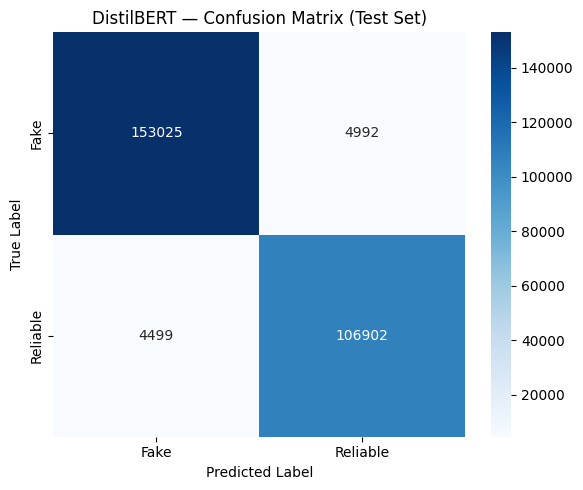

✅ Confusion matrix saved to Drive!


In [ ]:
# ============================================================
# CELL 9 — Final Test Evaluation
# ============================================================
from sklearn.metrics import (accuracy_score, f1_score,
                             precision_score, recall_score,
                             classification_report,
                             confusion_matrix)
import seaborn as sns
import matplotlib.pyplot as plt

best_model_path = "/content/drive/MyDrive/LUT-FakeNewsDetection/best_distilbert.pt"

# Load best model weights
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.eval()
print("Best model loaded for final evaluation")

# Run on full test set (269k rows)
print("Running on full test set — this will take ~30 mins...")
all_preds, all_labels = [], []

with torch.no_grad():
    for i, batch in enumerate(test_loader):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['label'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        preds   = torch.argmax(outputs.logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        if (i + 1) % 1000 == 0:
            print(f"  Batch {i+1:,}/{len(test_loader):,}")

# ── Metrics ───────────────────────────────────────────────
accuracy  = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, pos_label=1)
recall    = recall_score(all_labels, all_preds, pos_label=1)
f1        = f1_score(all_labels, all_preds, pos_label=1)

print("\n" + "=" * 62)
print("DISTILBERT — FINAL TEST RESULTS")
print("=" * 62)
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1        : {f1:.4f}")

print("\n── Comparison with Naive Bayes baseline ──")
print(f"{'Metric':<12} {'Naive Bayes':>12} {'DistilBERT':>12} {'Delta':>8}")
print("-" * 48)
for metric, nb, dl in [
    ("Accuracy",  0.8882, accuracy),
    ("Precision", 0.8807, precision),
    ("Recall",    0.9363, recall),
    ("F1",        0.9076, f1),
]:
    delta = dl - nb
    arrow = "✅" if delta > 0 else "❌"
    print(f"{metric:<12} {nb:>12.4f} {dl:>12.4f} {delta:>+8.4f} {arrow}")

# ── Classification report ─────────────────────────────────
print("\n── Classification Report ──")
print(classification_report(all_labels, all_preds,
                            target_names=['Fake (0)', 'Reliable (1)']))

# ── Confusion matrix ──────────────────────────────────────
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fake', 'Reliable'],
            yticklabels=['Fake', 'Reliable'])
plt.title('DistilBERT — Confusion Matrix (Test Set)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/LUT-FakeNewsDetection/confusion_matrix.png",
            dpi=150)
plt.show()
print("✅ Confusion matrix saved to Drive!")

In [ ]:
BASE_PATH = "/content/drive/My Drive/LUT-Fake News Detection/"

test_df = pd.read_csv(BASE_PATH + "test.csv")

LABEL_MAP = {
    'reliable'  : 1,
    'fake'      : 0,
    'unreliable': 0,
    'conspiracy': 0,
    'rumor'     : 0,
    'junksci'   : 0,
    'clickbait' : 0,
    'hate'      : 0,
    'satire'    : 0,
    'political' : None,
    'bias'      : None,
    'unknown'   : None,
}

test_df['label'] = test_df['type'].map(LABEL_MAP)
test_df = test_df.dropna(subset=['label'])
test_df['label'] = test_df['label'].astype(int)
test_df = test_df.reset_index(drop=True)

print(f"Test rows  : {len(test_df):,}")
print(f"Reliable   : {(test_df['label']==1).sum():,}")
print(f"Fake       : {(test_df['label']==0).sum():,}")

Test rows  : 269,418
Reliable   : 111,401
Fake       : 158,017


In [ ]:
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification
from torch.utils.data import Dataset, DataLoader

MAX_LEN    = 256
BATCH_SIZE = 32

class FakeNewsDataset(Dataset):
    def __init__(self, df, tokenizer, max_len):
        self.texts     = df['processed_text'].tolist()
        self.labels    = df['label'].tolist()
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length     = self.max_len,
            padding        = 'max_length',
            truncation     = True,
            return_tensors = 'pt'
        )
        return {
            'input_ids'      : encoding['input_ids'].squeeze(),
            'attention_mask' : encoding['attention_mask'].squeeze(),
            'label'          : torch.tensor(self.labels[idx], dtype=torch.long)
        }

# Load tokenizer
tokenizer    = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')

# Build test loader
test_dataset = FakeNewsDataset(test_df, tokenizer, MAX_LEN)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
print(f"Test batches: {len(test_loader):,}")

# Load model
model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased', num_labels=2
).to(device)

model.load_state_dict(torch.load(
    "/content/drive/MyDrive/LUT-FakeNewsDetection/best_distilbert.pt",
    map_location=device
))
model.eval()
print("✅ Model loaded and ready!")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Test batches: 8,420


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ Model loaded and ready!


# Trying out the LIAR dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!pip install transformers datasets -q

import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"GPU: {torch.cuda.get_device_name(0)}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cuda
GPU: Tesla T4


In [ ]:
import pandas as pd

# LIAR tsv has no header — these are the official column names
LIAR_COLUMNS = [
    'id', 'label', 'statement', 'subject', 'speaker',
    'job_title', 'state_info', 'party_affiliation',
    'barely_true_count', 'false_count', 'half_true_count',
    'mostly_true_count', 'pants_fire_count', 'context'
]

liar_df = pd.read_csv(
    "/content/drive/MyDrive/LUT-Fake News Detection/LIAR_dataset/test.tsv",
    sep='\t',
    header=None,
    names=LIAR_COLUMNS
)

print(f"Rows: {len(liar_df):,}")
print(f"\nLabel distribution:\n{liar_df['label'].value_counts()}")
print(f"\nSample row:\n{liar_df.iloc[0]}")

Rows: 1,267

Label distribution:
label
half-true      265
false          249
mostly-true    241
barely-true    212
true           208
pants-fire      92
Name: count, dtype: int64

Sample row:
id                                                          11972.json
label                                                             true
statement            Building a wall on the U.S.-Mexico border will...
subject                                                    immigration
speaker                                                     rick-perry
job_title                                                     Governor
state_info                                                       Texas
party_affiliation                                           republican
barely_true_count                                                   30
false_count                                                         30
half_true_count                                                     42
mostly_true_count          

## Apply Binary Mapping & Prep for DistilBERT

In [ ]:
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification
from torch.utils.data import Dataset, DataLoader

# Binary mapping — same logic as FakeNewsCorpus
LIAR_MAP = {
    'true'        : 1,  # Reliable
    'mostly-true' : 1,  # Reliable
    'half-true'   : 1,  # Borderline — treated as reliable
    'barely-true' : 0,  # Fake
    'false'       : 0,  # Fake
    'pants-fire'  : 0,  # Fake (most extreme)
}

liar_df['binary_label'] = liar_df['label'].map(LIAR_MAP)
liar_df = liar_df.dropna(subset=['binary_label'])
liar_df['binary_label'] = liar_df['binary_label'].astype(int)

print(f"Rows after mapping : {len(liar_df):,}")
print(f"Reliable (1)       : {(liar_df['binary_label']==1).sum():,}")
print(f"Fake     (0)       : {(liar_df['binary_label']==0).sum():,}")

# ── Dataset class (same as before but uses 'statement' column) ──
MAX_LEN    = 256
BATCH_SIZE = 32

class LIARDataset(Dataset):
    def __init__(self, df, tokenizer, max_len):
        self.texts     = df['statement'].tolist()
        self.labels    = df['binary_label'].tolist()
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            str(self.texts[idx]),  # str() just in case of any NaN
            max_length     = self.max_len,
            padding        = 'max_length',
            truncation     = True,
            return_tensors = 'pt'
        )
        return {
            'input_ids'      : encoding['input_ids'].squeeze(),
            'attention_mask' : encoding['attention_mask'].squeeze(),
            'label'          : torch.tensor(self.labels[idx], dtype=torch.long)
        }

# Load tokenizer & build loader
tokenizer     = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')
liar_dataset  = LIARDataset(liar_df, tokenizer, MAX_LEN)
liar_loader   = DataLoader(liar_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"\nLIAR batches: {len(liar_loader):,}")

Rows after mapping : 1,267
Reliable (1)       : 714
Fake     (0)       : 553


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]


LIAR batches: 40


## Load the Trained Model

In [ ]:
model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased', num_labels=2
).to(device)

model.load_state_dict(torch.load(
    "/content/drive/MyDrive/LUT-FakeNewsDetection/best_distilbert.pt",
    map_location=device
))
model.eval()
print("✅ Model loaded!")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ Model loaded!


## Full LIAR evaluation

DISTILBERT — LIAR CROSS-DOMAIN RESULTS
Accuracy  : 0.5107
Precision : 0.5867
Recall    : 0.4454
F1        : 0.5064

── vs FakeNewsCorpus Test Results ──
Metric        FakeNewsCorpus       LIAR    Delta
------------------------------------------------
Accuracy              0.9648     0.5107  -0.4541 🔻
Precision             0.9554     0.5867  -0.3687 🔻
Recall                0.9596     0.4454  -0.5142 🔻
F1                    0.9575     0.5064  -0.4511 🔻

── Classification Report ──
              precision    recall  f1-score   support

    Fake (0)       0.45      0.59      0.51       553
Reliable (1)       0.59      0.45      0.51       714

    accuracy                           0.51      1267
   macro avg       0.52      0.52      0.51      1267
weighted avg       0.53      0.51      0.51      1267



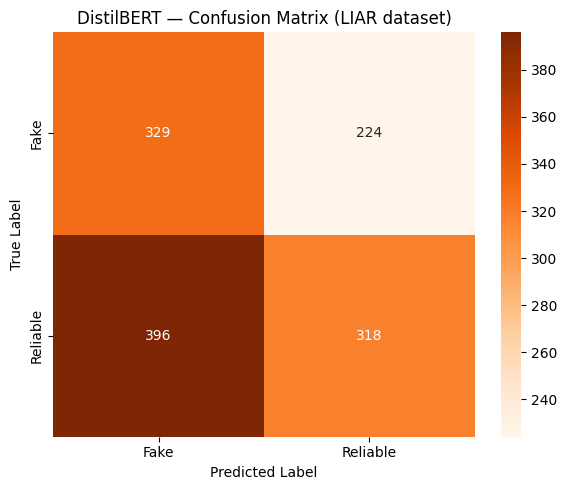

LIAR confusion matrix saved!


In [ ]:
from sklearn.metrics import (accuracy_score, f1_score,
                             precision_score, recall_score,
                             classification_report,
                             confusion_matrix)
import seaborn as sns
import matplotlib.pyplot as plt

all_preds, all_labels = [], []

with torch.no_grad():
    for batch in liar_loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['label'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        preds   = torch.argmax(outputs.logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

accuracy  = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, pos_label=1)
recall    = recall_score(all_labels, all_preds, pos_label=1)
f1        = f1_score(all_labels, all_preds, pos_label=1)

print("=" * 62)
print("DISTILBERT — LIAR CROSS-DOMAIN RESULTS")
print("=" * 62)
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1        : {f1:.4f}")

print("\n── vs FakeNewsCorpus Test Results ──")
print(f"{'Metric':<12} {'FakeNewsCorpus':>15} {'LIAR':>10} {'Delta':>8}")
print("-" * 48)
for metric, fnc, liar in [
    ("Accuracy",  0.9648, accuracy),
    ("Precision", 0.9554, precision),
    ("Recall",    0.9596, recall),
    ("F1",        0.9575, f1),
]:
    delta = liar - fnc
    arrow = "✔️" if delta > 0 else "🔻"
    print(f"{metric:<12} {fnc:>15.4f} {liar:>10.4f} {delta:>+8.4f} {arrow}")

print("\n── Classification Report ──")
print(classification_report(all_labels, all_preds,
                            target_names=['Fake (0)', 'Reliable (1)']))

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Fake', 'Reliable'],
            yticklabels=['Fake', 'Reliable'])
plt.title('DistilBERT — Confusion Matrix (LIAR dataset)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/LUT-FakeNewsDetection/confusion_matrix_liar.png",
            dpi=150)
plt.show()
print("LIAR confusion matrix saved!")